In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("cleaned_logistics_dataset.csv")

df.head()

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,delivery_partner_blue dart,delivery_partner_delhivery,delivery_partner_dhl,...,region_south,region_west,weather_condition_cold,weather_condition_foggy,weather_condition_hot,weather_condition_rainy,weather_condition_stormy,delayed_yes,delivery_status_delivered,delivery_status_failed
0,250.99,0.999659,0.947595,0.421053,0.272727,0.50,1.000000,False,True,False,...,False,True,False,False,False,False,False,False,True,False
1,250.99,0.293015,0.956397,0.105263,0.045455,1.00,0.354251,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,250.99,0.919591,0.536745,0.526316,0.636364,0.75,0.879932,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,250.99,0.906644,0.246059,0.315789,0.272727,0.50,0.904915,False,False,True,...,False,False,True,False,False,False,False,False,True,False
4,250.99,0.862351,0.744115,0.473684,0.636364,0.75,0.845054,False,False,True,...,False,False,False,True,False,False,False,False,True,False


In [4]:
print(df.columns.tolist())

['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delivery_rating', 'delivery_cost', 'delivery_partner_blue dart', 'delivery_partner_delhivery', 'delivery_partner_dhl', 'delivery_partner_ecom express', 'delivery_partner_ekart', 'delivery_partner_fedex', 'delivery_partner_shadowfax', 'delivery_partner_xpressbees', 'package_type_clothing', 'package_type_cosmetics', 'package_type_documents', 'package_type_electronics', 'package_type_fragile items', 'package_type_furniture', 'package_type_groceries', 'package_type_pharmacy', 'vehicle_type_ev bike', 'vehicle_type_ev van', 'vehicle_type_scooter', 'vehicle_type_truck', 'vehicle_type_van', 'delivery_mode_same day', 'delivery_mode_standard', 'delivery_mode_two day', 'region_east', 'region_north', 'region_south', 'region_west', 'weather_condition_cold', 'weather_condition_foggy', 'weather_condition_hot', 'weather_condition_rainy', 'weather_condition_stormy', 'delayed_yes', 'delivery_status_deliver

In [5]:
features = [
    'distance_km',
    'package_weight_kg',
    'expected_time_hours',
    'delivery_rating',
    'delivery_cost',
    
    'delivery_partner_blue dart',
    'delivery_partner_delhivery',
    'delivery_partner_dhl',
    'delivery_partner_ecom express',
    'delivery_partner_ekart',
    'delivery_partner_fedex',
    'delivery_partner_shadowfax',
    'delivery_partner_xpressbees',
    
    'vehicle_type_ev bike',
    'vehicle_type_ev van',
    'vehicle_type_scooter',
    'vehicle_type_truck',
    'vehicle_type_van',
    
    'weather_condition_cold',
    'weather_condition_foggy',
    'weather_condition_hot',
    'weather_condition_rainy',
    'weather_condition_stormy',
    
    'delayed_yes'
]

target = 'delivery_time_hours'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (25000, 24)
Target shape: (25000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20000, 24)
Testing data: (5000, 24)


In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
def evaluate_model(y_true, predictions, model_name):
    
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)
    
    print(f"\n{model_name}")
    print("-" * 30)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R² Score:", round(r2, 3))
    
    return [model_name, mae, rmse, r2]


linear_results = evaluate_model(
    y_test,
    linear_predictions,
    "Linear Regression"
)

rf_results = evaluate_model(
    y_test,
    rf_predictions,
    "Random Forest Regressor"
)


Linear Regression
------------------------------
MAE: 0.064
RMSE: 0.081
R² Score: 0.755

Random Forest Regressor
------------------------------
MAE: 0.064
RMSE: 0.082
R² Score: 0.751


In [10]:
results = pd.DataFrame(
    [linear_results, rf_results],
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.063773,0.081071,0.755067
1,Random Forest Regressor,0.063815,0.081723,0.751108


In [11]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

feature_importance['Absolute_Importance'] = abs(
    feature_importance['Coefficient']
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Importance
4,delivery_cost,0.197615,0.197615
22,weather_condition_stormy,0.193691,0.193691
0,distance_km,0.172699,0.172699
21,weather_condition_rainy,0.143139,0.143139
23,delayed_yes,0.085179,0.085179
19,weather_condition_foggy,0.077964,0.077964
2,expected_time_hours,0.077945,0.077945
1,package_weight_kg,-0.021952,0.021952
3,delivery_rating,0.004011,0.004011
5,delivery_partner_blue dart,0.002678,0.002678


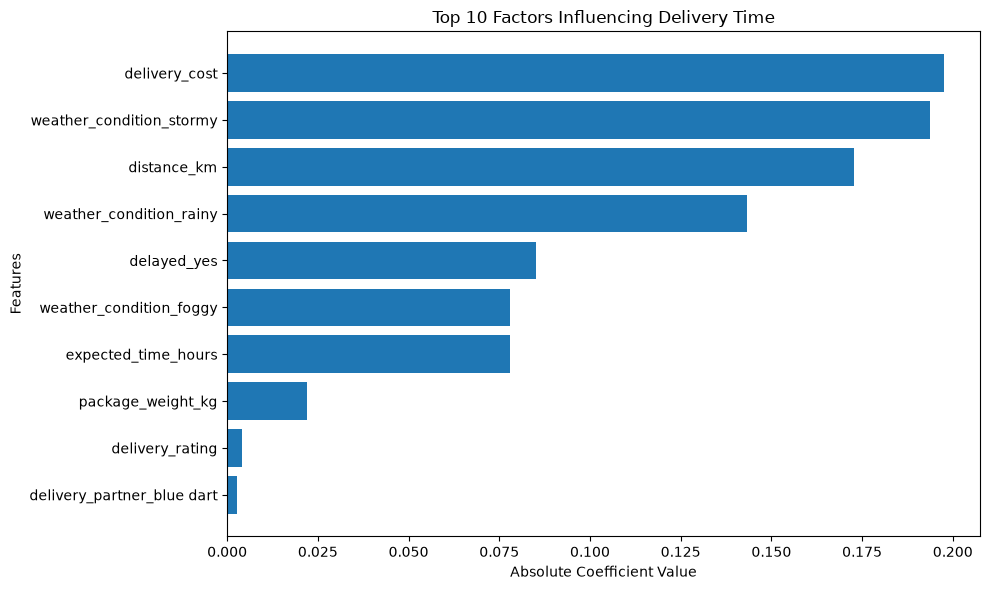

In [12]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Absolute_Importance']
)

plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.title("Top 10 Factors Influencing Delivery Time")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

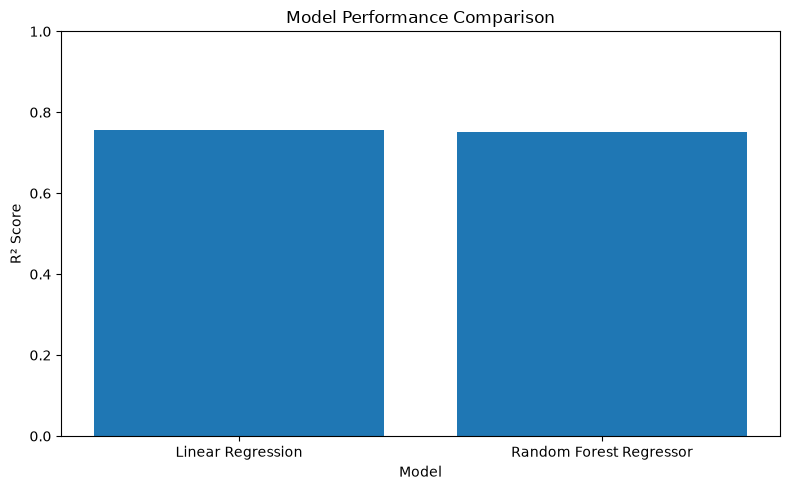

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig("model_comparison.png")

plt.show()

In [14]:
results_display = results.copy()

results_display['MAE'] = results_display['MAE'].round(3)
results_display['RMSE'] = results_display['RMSE'].round(3)
results_display['R2 Score'] = results_display['R2 Score'].round(3)

results_display

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.064,0.081,0.755
1,Random Forest Regressor,0.064,0.082,0.751


# Conclusion

This project developed predictive models to estimate delivery time in a logistics system. Linear Regression and Random Forest Regressor were trained and evaluated using MAE, RMSE, and R² score.

Linear Regression achieved the best overall performance with an MAE of 0.064, RMSE of 0.081, and an R² score of 0.755. The model was therefore selected as the preferred model for delivery time prediction.

Feature importance analysis showed that delivery cost, stormy weather, distance, rainy weather, and delivery delays were among the most influential factors affecting delivery time.

Based on these findings, optimization strategies such as weather-based planning, route optimization, proactive delay management, dynamic scheduling, and efficient resource allocation were recommended. These strategies can help logistics organizations reduce delivery delays, improve operational efficiency, and optimize transportation costs.